# Worksheet5: Writing a simple Subscriber/Publisher for Turtlebot3

This worksheet takes you through the basics of writing a publisher and subscriber for the turtlebot3 control. This notebook will guide you step by step to write all the steps and finally the full code is provided. 

By completing this worksheet, you will be better able to:

- **explain** the purpose and function of publisher and subscriber in ROS2
- **describe** how “messages”, “topics”, and “message types” work in ROS2
- **demonstrate** skills to use ROS messages to make two ROS processes communicate

**NOTE: This notebook is not an interactive one. You need to run the code in the form of scripts.**

As you have already created your workspace in the last exercise, lets use the same workspace. Open a new terminal and source it. Use the following command to get into the workspace

In [ ]:
cd ~/ros2_ws/src    ## Please note this could be any name. 

The first step is to open the turtlebot3 in Gazebo environment. Gazebo is a simulator environment which works well with ROS2. As the turtlebot3 is already installed for you in the VM, please use the following command in the terminal to open the gazebo. You need to first select the model of the turtlebot3, you want to bring in the environment. 

In [ ]:
export TURTLEBOT3_MODEL=waffle

Then use this command to launch the gazebo environment. 

In [ ]:
ros2 launch turtlebot3_gazebo turtlebot3_world.launch.py

It will open the gazebo as shown in the figure below

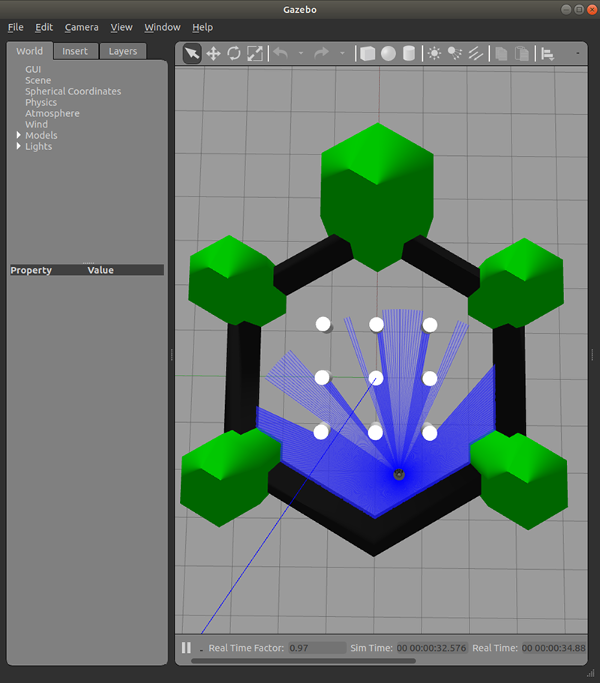

Now open another terminal and source it. Go to the package you have created in the last worksheet exercise using the following command

In [ ]:
cd ~/ros2_ws/src/unit1/unit1

You need to create a python file now in which you can write your program. Please name the file ```forward.py```. Open the file in a choice of editor (VS code for me).

## TASK:

You need to write a Publisher only to publish some velocity command on the /cmd_vel topic. 

Lets recall from the previous worksheet how you write the publisher and subscriber. Lets start in a same way. We import the rclpy library, from which we’ll create the publisher. We also import the Node class from rclpy.

In [ ]:
import rclpy
import rclpy.node as Node

Then, we need to bring the geometry_msgs/Twist as 

In [ ]:
from geometry_msgs.msg import Twist

You can see details about this using the command 

In [ ]:
ros2 interface show msg_name  ## Please use the msg type here

Lets write the class named Forward and initialize the required variables and publishers. As we use OOP in ROS2, we first create a class which inherits from the Node class. The first thing we do is to call super() and pass the name of the node.

In [ ]:
class Forward(Node):
    def __init__(self):
        super().__init__("control")
        self.forward_publisher_ = self.create_publisher(
            Twist, "cmd_vel", 10)
        self.forward_timer_ = self.create_timer(
            0.1, self.publish_velocity)
        
        self.robot = Twist()

we have created a timer that shows after how much time you want to publish on the cmd_vel. We initialized our robot as Twist(). 

To create a publisher with rclpy you simply have to call the create_publisher() function from rclpy. This function takes at least 3 arguments:

Message (or interface) type. We use the Twist type we’ve just imported before.
Topic name.
Queue size. This is kind of a buffer for messages in case some of them are late. Unless you send a lot of data at a high frequency, you probably don’t need to worry about that. I often use 10 as a default value.

Then, we need to write the publish function that will keep on publishing the command on the given time. For the simplest case, we just asked the linear velicity in x direction to move 0.5. 

In [ ]:
def publish_velocity(self):
        self.robot.linear.x = .5 

        self.forward_publisher_.publish(self.robot)

The main function goes like this

In [ ]:
def main(args=None):
    rclpy.init(args=args)
    node = Forward()
    rclpy.spin(node)
    rclpy.shutdown()

Nothing special here: we just init ROS2 communications, initialize the node, make the node spin, and finally shutdown ROS2 communications

We finish our script with the construct.

In [ ]:
if __name__ == "__main__":
    main()

The overall script looks like this:

In [ ]:
import rclpy
from rclpy.node import Node


from geometry_msgs.msg import Twist


class Forward(Node):
    def __init__(self):
        super().__init__("control")
        self.forward_publisher_ = self.create_publisher(
            Twist, "cmd_vel", 10)
        self.forward_timer_ = self.create_timer(
            0.1, self.publish_velocity)
        
        self.robot = Twist()
    
    def publish_velocity(self):
        self.robot.linear.x = .5 

        self.forward_publisher_.publish(self.robot)

def main(args=None):
    rclpy.init(args=args)
    node = Forward()
    rclpy.spin(node)
    rclpy.shutdown()

if __name__ == "__main__":
    main()

We can also write a subscriber function in the same way. We can subscribe to odometry values of the robot. 

## Task: write a subscriber for odom

In order to write a subscriber, we just need to import the odometry from the nav_msgs as

In [ ]:
from nav_msgs.msg import Odometry

We need to add the code to our previous code as 

In [ ]:
self.create_subscription(Odometry, 'odom', self.odom_callback, 10)

In order to get the information on the odometry, we need to write a call back function that can show us the current linear and angular positions. 

In [ ]:
def odom_callback(self, odom):
        self.get_logger().info('The odom values are "%s"' % odom)

The overall code looks like this now

In [ ]:
import rclpy
from rclpy.node import Node

from geometry_msgs.msg import Twist
from nav_msgs.msg import Odometry


class Forward(Node):
    def __init__(self):
        super().__init__("control")
        self.forward_publisher_ = self.create_publisher(
            Twist, "cmd_vel", 10)
        self.forward_timer_ = self.create_timer(
            0.1, self.publish_velocity)
        
        self.create_subscription(Odometry, 'odom', self.odom_callback, 10)

        
        self.robot = Twist()
    
    def publish_velocity(self):
        self.robot.linear.x = .5 

        self.forward_publisher_.publish(self.robot)

    def odom_callback(self, odom):
        self.get_logger().info('The odom values are "%s"' % odom)

def main(args=None):
    rclpy.init(args=args)
    node = Forward()
    rclpy.spin(node)
    rclpy.shutdown()

if __name__ == "__main__":
    main()

# Summary

You created two nodes to publish and subscribe to data over a topic for the turtlebot3. We have successfully moved the robot with a constant velocity and then see the values change using the odometry.